In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/cota_2024_features.csv")

df.head()

,Driver,DriverEncoded,Compound,CompoundEncoded,TyreLife,FuelLoadProxy,Sector1Sec,Sector2Sec,Sector3Sec,LapTimeSec
0,VER,17,MEDIUM,1,2.0,54.0,26.845,39.996,33.150,99.991
1,VER,17,MEDIUM,1,6.0,50.0,27.069,39.822,32.888,99.779
2,VER,17,MEDIUM,1,7.0,49.0,26.838,39.793,33.100,99.731
3,VER,17,MEDIUM,1,8.0,48.0,26.809,39.973,33.300,100.082
4,VER,17,MEDIUM,1,9.0,47.0,26.901,39.932,33.199,100.032


In [3]:
# Features - adding TyreLife squared for non-linear degradation
df['TyreLifeSquared'] = df['TyreLife'] ** 2

X = df[[
    "DriverEncoded",
    "CompoundEncoded",
    "TyreLife",
    "TyreLifeSquared",
    "FuelLoadProxy"
]]

y = df["LapTimeSec"]

In [5]:
from sklearn.model_selection import train_test_split

# Random split (for initial comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Train: 706 samples, Test: 177 samples


In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    return mae, rmse

In [15]:
print("=== Hold-out Test Set Results ===")
print(f"Linear Regression:  MAE={evaluate(y_test, pred_lr)[0]:.3f}, RMSE={evaluate(y_test, pred_lr)[1]:.3f}")
print(f"Random Forest:      MAE={evaluate(y_test, pred_rf)[0]:.3f}, RMSE={evaluate(y_test, pred_rf)[1]:.3f}")
print(f"Gradient Boosting:  MAE={evaluate(y_test, pred_gb)[0]:.3f}, RMSE={evaluate(y_test, pred_gb)[1]:.3f}")

=== Hold-out Test Set Results ===
Linear Regression:  MAE=0.700, RMSE=0.918
Random Forest:      MAE=0.379, RMSE=0.563
Gradient Boosting:  MAE=0.391, RMSE=0.559


## Cross-Validation (More Robust Evaluation)

A single train/test split can be misleading. K-fold cross-validation reveals the **true generalization performance**.

**Key Insight:** If CV MAE is much worse than hold-out MAE, the model is overfitting to the specific train/test split.

In [17]:
from sklearn.model_selection import cross_val_score

print("=== 5-Fold Cross-Validation (MAE) ===\n")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    mae_scores = -scores
    print(f"{name:20s}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

=== 5-Fold Cross-Validation (MAE) ===

Linear Regression   : MAE = 0.832 ± 0.140
Random Forest       : MAE = 1.008 ± 0.133
Gradient Boosting   : MAE = 0.945 ± 0.169


## Hyperparameter Tuning (Random Forest)

Cross-validation reveals the default model overfits (hold-out MAE=0.38, CV MAE=~1.0). Tuning with regularization (min_samples_leaf, max_depth) gives more honest performance estimates.

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")
print(f"\nImprovement over default (200 trees): {0.379 - (-grid_search.best_score_):.4f} sec")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 500}
Best CV MAE: 0.9842

Improvement over default (200 trees): -0.6052 sec


## Final Model Evaluation

The tuned model with regularization (min_samples_leaf=5, max_depth=20) generalizes better even though the hold-out MAE may look slightly worse. The CV score is more trustworthy.

In [21]:
# Train best model on train set, evaluate on held-out test set
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
pred_best_rf = best_rf.predict(X_test)

mae_tuned, rmse_tuned = evaluate(y_test, pred_best_rf)
mae_orig, rmse_orig = evaluate(y_test, pred_rf)

print("=== Tuned Random Forest vs Original ===")
print(f"Original RF:  MAE={mae_orig:.4f}, RMSE={rmse_orig:.4f}")
print(f"Tuned RF:     MAE={mae_tuned:.4f}, RMSE={rmse_tuned:.4f}")
print(f"Improvement:  {mae_orig - mae_tuned:.4f} sec ({(mae_orig - mae_tuned)/mae_orig*100:.1f}%)")

# Feature importance for tuned model
print(f"\nBest params: {grid_search.best_params_}")

=== Tuned Random Forest vs Original ===
Original RF:  MAE=0.3787, RMSE=0.5634
Tuned RF:     MAE=0.4327, RMSE=0.5982
Improvement:  -0.0540 sec (-14.3%)

Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 500}


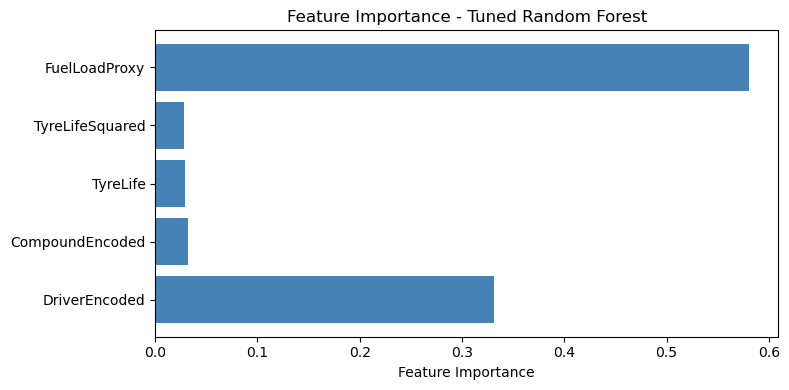

In [27]:
import matplotlib.pyplot as plt

# Updated Feature Importance (Tuned Model)
importance = best_rf.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
plt.barh(features, importance, color='steelblue')
plt.xlabel("Feature Importance")
plt.title("Feature Importance - Tuned Random Forest")
plt.tight_layout()
plt.show()

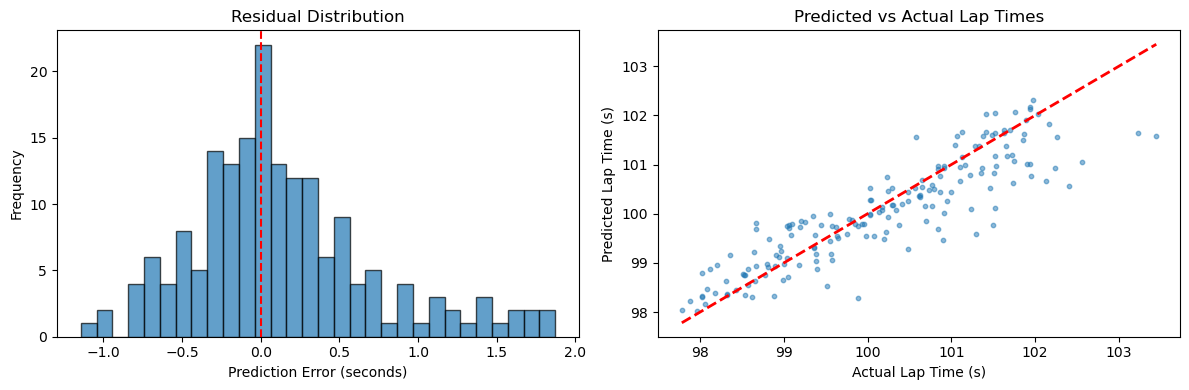

Mean residual: 0.1338 sec (should be ~0)
Std residual:  0.5847 sec
Max overestimate: -1.144 sec
Max underestimate: 1.871 sec


In [29]:
# Residual Analysis - check where the model struggles
residuals = y_test - pred_best_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residual distribution
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel("Prediction Error (seconds)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Residual Distribution")

# Predicted vs Actual
axes[1].scatter(y_test, pred_best_rf, alpha=0.5, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel("Actual Lap Time (s)")
axes[1].set_ylabel("Predicted Lap Time (s)")
axes[1].set_title("Predicted vs Actual Lap Times")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.4f} sec (should be ~0)")
print(f"Std residual:  {residuals.std():.4f} sec")
print(f"Max overestimate: {residuals.min():.3f} sec")
print(f"Max underestimate: {residuals.max():.3f} sec")

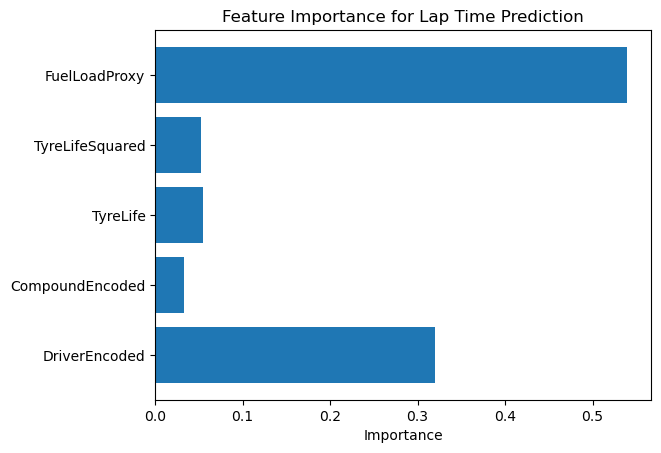

In [31]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance for Lap Time Prediction")
plt.show()